In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
people = pd.read_csv("D:/Games/TCS/01_people.csv")
abilities = pd.read_csv("D:/Games/TCS/02_abilities.csv")
education = pd.read_csv("D:/Games/TCS/03_education.csv")
experience = pd.read_csv("D:/Games/TCS/04_experience.csv")
person_skills = pd.read_csv("D:/Games/TCS/05_person_skills.csv")
skills = pd.read_csv("D:/Games/TCS/06_skills.csv")

In [3]:
people.head()

,person_id,name,email,phone,linkedin
0,1,Database Administrator,NaN,NaN,NaN
1,2,Database Administrator,NaN,NaN,NaN
2,3,Oracle Database Administrator,NaN,NaN,NaN
3,4,Amazon Redshift Administrator and ETL Develope...,NaN,NaN,NaN
4,5,Scrum Master Scrum Master Scrum Master,NaN,NaN,NaN


In [4]:
data = pd.merge(person_skills, skills, on="skill")
data = pd.merge(data, people, on="person_id")
data.head()

,person_id,skill,name,email,phone,linkedin
0,1,Database administration,Database Administrator,NaN,NaN,NaN
1,1,Database,Database Administrator,NaN,NaN,NaN
2,1,Ms sql server,Database Administrator,NaN,NaN,NaN
3,1,Ms sql server 2005,Database Administrator,NaN,NaN,NaN
4,1,Sql server,Database Administrator,NaN,NaN,NaN


In [5]:
data['skill'] = data['skill'].astype(str)

In [6]:
data = data.dropna(subset=['skill'])

In [7]:
resume_data = data.groupby('person_id')['skill'].apply(lambda x: " ".join(x)).reset_index()
resume_data.head()

,person_id,skill
0,1,Database administration Database Ms sql server...
1,2,sql server management studio visual studio sql...
2,3,DATABASES ORACLE (4 years) ORACLE 10G SQL LINU...
3,4,Maintain multiple database environments (Redsh...
4,5,Scrum Agile software development Product backl...


In [8]:
resume_data = resume_data.rename(columns={'skill': 'skills_text'})
resume_data.head()

,person_id,skills_text
0,1,Database administration Database Ms sql server...
1,2,sql server management studio visual studio sql...
2,3,DATABASES ORACLE (4 years) ORACLE 10G SQL LINU...
3,4,Maintain multiple database environments (Redsh...
4,5,Scrum Agile software development Product backl...


In [9]:
dataset = pd.merge(resume_data, people[['person_id','name']], on='person_id')
dataset.head()

,person_id,skills_text,name
0,1,Database administration Database Ms sql server...,Database Administrator
1,2,sql server management studio visual studio sql...,Database Administrator
2,3,DATABASES ORACLE (4 years) ORACLE 10G SQL LINU...,Oracle Database Administrator
3,4,Maintain multiple database environments (Redsh...,Amazon Redshift Administrator and ETL Develope...
4,5,Scrum Agile software development Product backl...,Scrum Master Scrum Master Scrum Master


In [10]:
dataset = dataset.dropna()
dataset = dataset.reset_index(drop=True)
dataset.head()

,person_id,skills_text,name
0,1,Database administration Database Ms sql server...,Database Administrator
1,2,sql server management studio visual studio sql...,Database Administrator
2,3,DATABASES ORACLE (4 years) ORACLE 10G SQL LINU...,Oracle Database Administrator
3,4,Maintain multiple database environments (Redsh...,Amazon Redshift Administrator and ETL Develope...
4,5,Scrum Agile software development Product backl...,Scrum Master Scrum Master Scrum Master


In [79]:
# Keep only top 50 job roles
top_classes = dataset['name'].value_counts().head(50).index

dataset = dataset[dataset['name'].isin(top_classes)]
dataset = dataset.reset_index(drop=True)

In [80]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
dataset['label'] = encoder.fit_transform(dataset['name'])

In [81]:
print(len(dataset))

14046


In [82]:
dataset = dataset.sample(min(20000, len(dataset)), random_state=42)

In [83]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=500)

X = vectorizer.fit_transform(dataset['skills_text'])  # ❌ NO toarray()
X = X.astype('float32')

y = dataset['label']

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [85]:
X_train = X_train.toarray()
X_test = X_test.toarray()

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [86]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

# ✅ Step 1 fix (Input layer instead of input_shape)
model.add(Input(shape=(X.shape[1],)))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))   # ✅ Step 2 fix

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))   # ✅ Step 2 fix

# Output layer
model.add(Dense(len(dataset['label'].unique()), activation='softmax'))

In [87]:
input_shape=(X.shape[1],)

In [88]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [89]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop])

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3303 - loss: 2.9699 - val_accuracy: 0.4626 - val_loss: 2.2044
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4458 - loss: 2.1278 - val_accuracy: 0.5067 - val_loss: 1.7871
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 1.7821 - val_accuracy: 0.5409 - val_loss: 1.5826
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5381 - loss: 1.5544 - val_accuracy: 0.5716 - val_loss: 1.4285
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5774 - loss: 1.3844 - val_accuracy: 0.6054 - val_loss: 1.3266
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6158 - loss: 1.2508 - val_accuracy: 0.6201 - val_loss: 1.2513
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6393 - loss: 1.1563 - val_accuracy: 0.6619 - val_loss: 1.1607
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6733 - loss: 1.0610 - val_accuracy: 0.

In [90]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8480 - loss: 0.6413
Accuracy: 0.8480427265167236


In [92]:
model.save("resume_model.keras")
import joblib
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

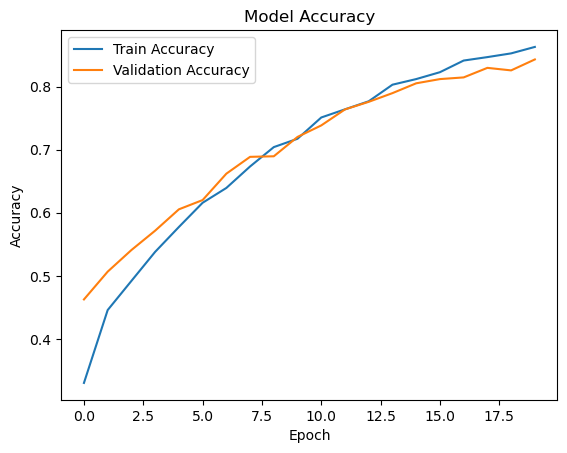

In [93]:
import matplotlib.pyplot as plt
# Training accuracy
plt.plot(history.history['accuracy'])
# Validation accuracy
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

In [95]:
import os
print(os.listdir())

['.ipynb_checkpoints', '01_people.csv', '02_abilities.csv', '03_education.csv', '04_experience.csv', '05_person_skills.csv', '06_skills.csv', 'encoder.pkl', 'Job Role Prediction from Resume Skills using Deep Learning.ipynb', 'resume_model.h5', 'resume_model.keras', 'Untitled.ipynb', 'vectorizer.pkl']


In [72]:
import os
print(os.getcwd())

C:\Users\nithi\anaconda 3\Final Project


In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

# ✅ FIX 1: Add Input layer (no warning)
model.add(Input(shape=(X.shape[1],)))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))   # ✅ FIX 2: reduced dropout

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))   # ✅ FIX 2: reduced dropout

# Output layer
model.add(Dense(len(dataset['label'].unique()), activation='softmax'))